Report column definitions

School District/Special District/Technical College – name of the district, if applicable
School/Special/Tech Code – district code, if applicable
County – county where the TID is located
CoMun – county municipal code where the TID is located
TVC – municipality type (town, village, city)
Municipality – name of the city, village or town where the TID is located
TID – number the municipality assigned to the TID
Base Yr – year the TID was created
Current Value – equalized value of all property within the TID for the current year
Base Value – equalized value of all property within the TID as of January 1 of the base year
Increment
Difference between the current value and the base value
Municipality uses the property taxes it collects on the increment value to pay eligible TID project costs (sec. 60.85(6)(c), 66.1105(6)(b), 66.1106(8), Wis. Stats.)

Negative increment is considered zero, generating no revenue for the municipality

Net Adjustment – if a TID has multiple school districts, technical colleges or specials districts, the district with the negative value is subtracted from the district with the positive value

In [3]:
### First let's import the raw data set of active TIDs in 2025
import pandas as pd 
df_2025 = pd.read_excel("2025_TIF_Raw_Data_FINAL.xlsx")
df_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   County          1445 non-null   str  
 1   CoMun           1445 non-null   int64
 2   TVC             1445 non-null   str  
 3   Municipality    1445 non-null   str  
 4   TID             1445 non-null   str  
 5    Base Yr        1445 non-null   int64
 6    Current Value  1445 non-null   int64
 7    Base Value     1445 non-null   int64
 8    Increment      1445 non-null   int64
dtypes: int64(5), str(4)
memory usage: 101.7 KB


In [4]:
## First, we want to eliminate duplicates and ensure each record is unique. To do that, we use the combination of municipality and TID number as a potential unique identifier and then check whether that combination appears only once in the dataset.
## Check for duplicate Municipality + TID combinations
duplicate_count = df_2025.duplicated(
    subset=["Municipality", "TID"]
).sum()

print(f"Number of duplicate Municipality-TID combinations: {duplicate_count}")

Number of duplicate Municipality-TID combinations: 23


In [5]:
# Display all records with duplicated Municipality + TID combinations
# These are not true duplicate districts. They are multi-county TIDs that appear once for each county, with the valuation data split across county lines.
duplicates = df_2025[
    df_2025.duplicated(
        subset=["Municipality", "TID"],
        keep=False
    )
].sort_values(["Municipality", "TID"])

duplicates

,County,CoMun,TVC,Municipality,TID,Base Yr,Current Value,Base Value,Increment
134,CLARK,10201,CITY,ABBOTSFORD,005,2008,2116800,458800,1658000
656,MARATHON,37201,CITY,ABBOTSFORD,005,2008,16092000,11303500,4788500
135,CLARK,10201,CITY,ABBOTSFORD,006,2016,38271600,2301900,35969700
657,MARATHON,37201,CITY,ABBOTSFORD,006,2016,28216300,5541200,22675100
174,DANE,13106,VILLAGE,BELLEVILLE,005,2009,9877500,6990200,2887300
409,GREEN,23106,VILLAGE,BELLEVILLE,005,2009,516400,368800,147600
436,IOWA,25108,VILLAGE,BLANCHARDVILLE,001,2024,785500,681900,103600
577,LAFAYETTE,33108,VILLAGE,BLANCHARDVILLE,001,2024,5485800,4838100,647700
415,GREEN,23206,CITY,BRODHEAD,006,2006,3931500,1170300,2761200
1051,ROCK,53210,CITY,BRODHEAD,006,2006,6555700,102100,6453600


In [6]:
## So rather than simply dropping duplicates, let's collapse each Municipality + TID combination into a single record and sum the financial values.
## Remove leading and trailing whitespace from all column names
df_2025.columns = df_2025.columns.str.strip()

# Check the cleaned column names
print(df_2025.columns.tolist())

# Check whether any Municipality + TID combinations
# have more than one Base Yr

base_year_check = (
    df_2025
    .groupby(["Municipality", "TID"])["Base Yr"]
    .nunique()
)

inconsistent_base_years = base_year_check[
    base_year_check > 1
]

print("TIDs with inconsistent base years:")
print(inconsistent_base_years)

# Collapse multi-county TIDs into one record per Municipality + TID

df_2025_clean = (
    df_2025
    .groupby(["Municipality", "TID"], as_index=False)
    .agg(
        County=("County", lambda x: ", ".join(sorted(x.unique()))),
        CoMun=("CoMun", lambda x: ", ".join(map(str, sorted(x.unique())))),
        TVC=("TVC", lambda x: ", ".join(sorted(x.unique()))),
        **{
            "Base Yr": ("Base Yr", "first"),
            "Current Value": ("Current Value", "sum"),
            "Base Value": ("Base Value", "sum"),
            "Increment": ("Increment", "sum")
        }
    )
)

df_2025_clean.head()

['County', 'CoMun', 'TVC', 'Municipality', 'TID', 'Base Yr', 'Current Value', 'Base Value', 'Increment']
TIDs with inconsistent base years:
Series([], Name: Base Yr, dtype: int64)


,Municipality,TID,County,CoMun,TVC,Base Yr,Current Value,Base Value,Increment
0,ABBOTSFORD,005,"CLARK , MARA...","10201, 37201",CITY,2008,18208800,11762300,6446500
1,ABBOTSFORD,006,"CLARK , MARA...","10201, 37201",CITY,2016,66487900,7843100,58644800
2,ABBOTSFORD,007,CLARK,10201,CITY,2016,2081900,1267400,814500
3,ALGOMA,001,KEWAUNEE,31201,CITY,2005,12602500,7032200,5570300
4,ALGOMA,001A,WINNEBAGO,70002,TOWN,2024,1899200,1861700,37500


In [7]:
# Check that Municipality + TID is now truly unique

print(
    "Duplicate Municipality-TID combinations:",
    df_2025_clean.duplicated(
        subset=["Municipality", "TID"]
    ).sum()
)

print("Original records:", len(df_2025))
print("Cleaned records:", len(df_2025_clean))

Duplicate Municipality-TID combinations: 0
Original records: 1445
Cleaned records: 1422


In [8]:
# Validate the Increment calculation

df_2025_clean["Calculated Increment"] = (
    df_2025_clean["Current Value"] - df_2025_clean["Base Value"]
)

# Find records where the reported and calculated increments differ
increment_errors = df_2025_clean[
    df_2025_clean["Increment"] != df_2025_clean["Calculated Increment"]
]

print(f"Records with incorrect Increment: {len(increment_errors)}")

# Check for missing values in key fields

key_columns = [
    "Municipality",
    "TID",
    "Base Yr",
    "Current Value",
    "Base Value",
    "Increment"
]

missing_values = df_2025_clean[key_columns].isna().sum()

print(missing_values)
# Check for negative property values

negative_values = df_2025_clean[
    (df_2025_clean["Current Value"] < 0) |
    (df_2025_clean["Base Value"] < 0)
]

print(f"Records with negative property values: {len(negative_values)}")

# Remove temporary validation column

df_2025_clean = df_2025_clean.drop(
    columns=["Calculated Increment"]
)

print(df_2025_clean.columns.tolist())

Records with incorrect Increment: 0
Municipality     0
TID              0
Base Yr          0
Current Value    0
Base Value       0
Increment        0
dtype: int64
Records with negative property values: 0
['Municipality', 'TID', 'County', 'CoMun', 'TVC', 'Base Yr', 'Current Value', 'Base Value', 'Increment']


In [9]:
## First order of business. Let's rank TIDs by property value added (Increment)
# Rank the top 25 TIDs by property value added (Increment)

top_25_tids = (
    df_2025_clean
    .sort_values("Increment", ascending=False)
    .head(25)
    .copy()
)

# Add rank
top_25_tids.insert(
    0,
    "Rank",
    range(1, len(top_25_tids) + 1)
)

# Display the top 25 with key fields
top_25_tids[
    ["Rank", "County", "Municipality", "TID", "Base Yr",
     "Base Value", "Current Value", "Increment"]
]

# Create a readable version for reporting

top_25_readable = top_25_tids[
    ["Rank", "County", "Municipality", "TID", "Base Yr",
     "Base Value", "Current Value", "Increment"]
].copy()

# Format dollar values
for col in ["Base Value", "Current Value", "Increment"]:
    top_25_readable[col] = top_25_readable[col].map(
        lambda x: f"${x:,.0f}"
    )

# Display the formatted table
top_25_readable

,Rank,County,Municipality,TID,Base Yr,Base Value,Current Value,Increment
834,1,RACINE,MOUNT PLEASANT,005,2018,"$30,231,500","$1,731,609,100","$1,701,377,600"
607,2,DANE,MADISON,036,2005,"$92,660,300","$779,145,900","$686,485,600"
721,3,DANE,MIDDLETON,003,1993,"$48,183,300","$724,421,700","$676,238,400"
34,4,BROWN,ASHWAUBENON,003,2008,"$322,615,000","$859,572,000","$536,957,000"
613,5,DANE,MADISON,046,2015,"$286,649,600","$805,558,900","$518,909,300"
735,6,MILWAUKEE,MILWAUKEE,048,2002,"$43,865,000","$479,832,600","$435,967,600"
563,7,SAUK,LAKE DELTON,003,2005,"$43,963,700","$476,851,900","$432,888,200"
757,8,MILWAUKEE,MILWAUKEE,078,2013,"$49,588,500","$414,464,100","$364,875,600"
974,9,KENOSHA,PLEASANT PRAIRIE,005,2017,"$25,069,900","$384,520,500","$359,450,600"
614,10,DANE,MADISON,048,2021,"$232,127,900","$570,509,300","$338,381,400"


In [10]:
# Calculate total incremental value across all 1,422 TIDs

total_increment = df_2025_clean["Increment"].sum()

# Calculate cumulative increment for the top 10, 25, 50 and 100 TIDs

top_10_increment = (
    df_2025_clean
    .nlargest(10, "Increment")["Increment"]
    .sum()
)

top_25_increment = (
    df_2025_clean
    .nlargest(25, "Increment")["Increment"]
    .sum()
)

top_50_increment = (
    df_2025_clean
    .nlargest(50, "Increment")["Increment"]
    .sum()
)

top_100_increment = (
    df_2025_clean
    .nlargest(100, "Increment")["Increment"]
    .sum()
)

# Calculate each group's share of total statewide increment

top_10_share = top_10_increment / total_increment * 100
top_25_share = top_25_increment / total_increment * 100
top_50_share = top_50_increment / total_increment * 100
top_100_share = top_100_increment / total_increment * 100

# Print results

print(f"Total statewide increment: ${total_increment:,.0f}")
print(f"Top 10 increment: ${top_10_increment:,.0f} ({top_10_share:.1f}%)")
print(f"Top 25 increment: ${top_25_increment:,.0f} ({top_25_share:.1f}%)")
print(f"Top 50 increment: ${top_50_increment:,.0f} ({top_50_share:.1f}%)")
print(f"Top 100 increment: ${top_100_increment:,.0f} ({top_100_share:.1f}%)")

# Create a summary table

concentration_summary = pd.DataFrame({
    "Group": ["Top 10", "Top 25", "Top 50", "Top 100"],
    "TID Count": [10, 25, 50, 100],
    "Increment": [
        top_10_increment,
        top_25_increment,
        top_50_increment,
        top_100_increment
    ],
    "Share of Total": [
        top_10_share,
        top_25_share,
        top_50_share,
        top_100_share
    ]
})

# Format for readability

concentration_summary["Increment"] = concentration_summary[
    "Increment"
].map(lambda x: f"${x:,.0f}")

concentration_summary["Share of Total"] = concentration_summary[
    "Share of Total"
].map(lambda x: f"{x:.1f}%")

concentration_summary

Total statewide increment: $46,675,718,763
Top 10 increment: $6,051,531,300 (13.0%)
Top 25 increment: $10,127,328,200 (21.7%)
Top 50 increment: $14,875,957,700 (31.9%)
Top 100 increment: $21,567,878,000 (46.2%)


,Group,TID Count,Increment,Share of Total
0,Top 10,10,"$6,051,531,300",13.0%
1,Top 25,25,"$10,127,328,200",21.7%
2,Top 50,50,"$14,875,957,700",31.9%
3,Top 100,100,"$21,567,878,000",46.2%


In [11]:
top_10_increment = (
    df_2025_clean
    .nlargest(10, "Increment")["Increment"]
    .sum()
)

top_10_share = top_10_increment / total_increment * 100

top_10_share

np.float64(12.965052194969237)

In [12]:
# Median increment across all 1,422 TIDs
median_increment_all = df_2025_clean["Increment"].median()

# Median increment among the top 25 TIDs
top_25 = df_2025_clean.nlargest(25, "Increment")
median_increment_top_25 = top_25["Increment"].median()

# Median increment among the top 5 TIDs
top_5 = df_2025_clean.nlargest(5, "Increment")
median_increment_top_5 = top_5["Increment"].median()

# Compare top-25 and top-5 medians with the statewide median
median_multiple_top_25 = median_increment_top_25 / median_increment_all
median_multiple_top_5 = median_increment_top_5 / median_increment_all

# Print results
print(f"Median increment — all 1,422 TIDs: ${median_increment_all:,.0f}")
print(f"Median increment — top 25 TIDs: ${median_increment_top_25:,.0f}")
print(f"Median increment — top 5 TIDs: ${median_increment_top_5:,.0f}")

print(
    f"The median increment among the top 25 TIDs "
    f"is {median_multiple_top_25:.1f} times the statewide median."
)

print(
    f"The median increment among the top 5 TIDs "
    f"is {median_multiple_top_5:.1f} times the statewide median."
)

Median increment — all 1,422 TIDs: $10,722,550
Median increment — top 25 TIDs: $300,337,300
Median increment — top 5 TIDs: $676,238,400
The median increment among the top 25 TIDs is 28.0 times the statewide median.
The median increment among the top 5 TIDs is 63.1 times the statewide median.


In [13]:
# Identify TIDs with negative increments

negative_tids = (
    df_2025_clean[
        df_2025_clean["Increment"] < 0
    ]
    .sort_values("Increment")
    .copy()
)

# Calculate count and percentage

negative_count = len(negative_tids)
total_tids = len(df_2025_clean)
negative_share = negative_count / total_tids * 100

print(f"TIDs with negative increments: {negative_count}")
print(f"Total TIDs: {total_tids}")
print(f"Share of TIDs with negative increments: {negative_share:.1f}%")

TIDs with negative increments: 38
Total TIDs: 1422
Share of TIDs with negative increments: 2.7%


In [14]:
# Identify TIDs with negative increments

negative_tids = (
    df_2025_clean[
        df_2025_clean["Increment"] < 0
    ]
    .sort_values("Increment")
    .copy()
)

# Count negative-increment TIDs
negative_count = len(negative_tids)

# Count all active TIDs
total_tids = len(df_2025_clean)

# Calculate share of active TIDs
negative_share = negative_count / total_tids * 100

print(f"Negative-increment TIDs: {negative_count}")
print(f"Total active TIDs: {total_tids}")
print(f"Share with negative increments: {negative_share:.1f}%")

# Create a readable table
negative_tids_readable = negative_tids[
    ["County", "Municipality", "TID", "Base Yr",
     "Base Value", "Current Value", "Increment"]
].copy()

# Format dollar values
for col in ["Base Value", "Current Value", "Increment"]:
    negative_tids_readable[col] = negative_tids_readable[col].map(
        lambda x: f"${x:,.0f}"
    )

negative_tids_readable

Negative-increment TIDs: 38
Total active TIDs: 1422
Share with negative increments: 2.7%


,County,Municipality,TID,Base Yr,Base Value,Current Value,Increment
792,MILWAUKEE,MILWAUKEE,115,2023,"$86,268,800","$62,559,800","$-23,709,000"
696,WAUKESHA,MENOMONEE FALLS,017,2024,"$25,118,600","$10,969,700","$-14,148,900"
523,KENOSHA,KENOSHA,036,2024,"$8,910,500","$2,264,200","$-6,646,300"
1022,RACINE,RACINE,016,2009,"$38,217,400","$32,607,800","$-5,609,600"
1006,SAUK,PRAIRIE DU SAC,005,2018,"$17,192,300","$12,671,100","$-4,521,200"
340,OUTAGAMIE,FREEDOM,003A,2023,"$5,675,800","$3,257,900","$-2,417,900"
550,LA CROSSE,LA CROSSE,019,2020,"$5,061,100","$3,889,300","$-1,171,800"
388,BROWN,GREEN BAY,029,2024,"$2,749,800","$1,673,100","$-1,076,700"
776,MILWAUKEE,MILWAUKEE,098,2019,"$1,482,800","$423,500","$-1,059,300"
714,LINCOLN,MERRILL,009,2013,"$5,936,000","$5,086,000","$-850,000"


In [15]:
# Calculate total negative increment

total_negative_increment = negative_tids["Increment"].sum()

print(
    f"Total negative increment: "
    f"${total_negative_increment:,.0f}"
)

Total negative increment: $-66,187,800


In [16]:
# Median increment among the 38 TIDs with negative increments

median_negative_increment = negative_tids["Increment"].median()

print(
    f"Median negative increment: "
    f"${median_negative_increment:,.0f}"
)
# Median decline in property value among TIDs with negative increments

median_decline = abs(
    negative_tids["Increment"].median()
)

print(
    f"Median decline among TIDs below base value: "
    f"${median_decline:,.0f}"
)

Median negative increment: $-198,700
Median decline among TIDs below base value: $198,700


In [17]:
# Identify the middle: all TIDs outside the top 100

top_100_indices = (
    df_2025_clean
    .nlargest(100, "Increment")
    .index
)

middle_tids = df_2025_clean[
    ~df_2025_clean.index.isin(top_100_indices)
].copy()

# Calculate key statistics

middle_count = len(middle_tids)
middle_increment = middle_tids["Increment"].sum()
middle_median = middle_tids["Increment"].median()
middle_mean = middle_tids["Increment"].mean()
middle_share = middle_increment / total_increment * 100

print(f"Middle TIDs: {middle_count}")
print(f"Middle increment: ${middle_increment:,.0f}")
print(f"Middle share of statewide increment: {middle_share:.1f}%")
print(f"Middle median increment: ${middle_median:,.0f}")
print(f"Middle mean increment: ${middle_mean:,.0f}")

Middle TIDs: 1322
Middle increment: $25,107,840,763
Middle share of statewide increment: 53.8%
Middle median increment: $9,006,500
Middle mean increment: $18,992,315


In [18]:
# Find the oldest Base Year among active 2025 TIDs

oldest_base_year = df_2025_clean["Base Yr"].min()

print(f"Oldest active TID base year: {oldest_base_year}")
# Show all active TIDs created in the oldest year

oldest_year_tids = (
    df_2025_clean[
        df_2025_clean["Base Yr"] == oldest_base_year
    ]
    .sort_values("Increment", ascending=False)
    .copy()
)

oldest_year_tids[
    ["County", "Municipality", "TID", "Base Yr",
     "Base Value", "Current Value", "Increment"]
]

Oldest active TID base year: 1989


,County,Municipality,TID,Base Yr,Base Value,Current Value,Increment
496,KENOSHA,KENOSHA,004,1989,15566200,195064000,179497800


In [19]:
# Look at TIDs created before 2000

old_tids = (
    df_2025_clean[
        df_2025_clean["Base Yr"] < 2000
    ]
    .copy()
)

print(f"TIDs created before 2000: {len(old_tids)}")
print(
    f"Base years represented: "
    f"{old_tids['Base Yr'].min()}–{old_tids['Base Yr'].max()}"
)
# Rank pre-2000 TIDs by property value added

oldest_high_value = (
    old_tids
    .sort_values("Increment", ascending=False)
    .head(25)
    .copy()
)

# Add rank
oldest_high_value.insert(
    0,
    "Rank",
    range(1, len(oldest_high_value) + 1)
)

# Create readable version

oldest_high_value_readable = oldest_high_value[
    ["Rank", "County", "Municipality", "TID", "Base Yr",
     "Base Value", "Current Value", "Increment"]
].copy()

# Format dollar values

for col in ["Base Value", "Current Value", "Increment"]:
    oldest_high_value_readable[col] = oldest_high_value_readable[col].map(
        lambda x: f"${x:,.0f}"
    )

oldest_high_value_readable

TIDs created before 2000: 68
Base years represented: 1989–1999


,Rank,County,Municipality,TID,Base Yr,Base Value,Current Value,Increment
721,1,DANE,MIDDLETON,003,1993,"$48,183,300","$724,421,700","$676,238,400"
1382,2,MARATHON,WESTON,001,1998,"$38,651,600","$321,186,700","$282,535,100"
496,3,KENOSHA,KENOSHA,004,1989,"$15,566,200","$195,064,000","$179,497,800"
497,4,KENOSHA,KENOSHA,005,1994,"$319,700","$172,955,300","$172,635,600"
1332,5,MARATHON,WAUSAU,003,1994,"$34,544,200","$174,944,200","$140,400,000"
354,6,MILWAUKEE,GLENDALE,007,1996,"$13,408,500","$134,101,300","$120,692,800"
1301,7,WAUKESHA,WAUKESHA,011,1997,"$33,833,500","$150,387,800","$116,554,300"
1365,8,WASHINGTON,WEST BEND,004,1997,"$829,900","$104,532,700","$103,702,800"
1208,9,DOOR,STURGEON BAY,002,1994,"$14,128,800","$114,667,300","$100,538,500"
1288,10,MONROE,WARRENS,001,1998,"$8,113,400","$95,800,300","$87,686,900"


In [20]:
# Add age of each TID as of 2025. Then we have the oldest active districts that have accumulated the most value. 

oldest_high_value_readable["Age in 2025"] = (
    2025 - oldest_high_value["Base Yr"]
)

# Reorder columns

oldest_high_value_readable = oldest_high_value_readable[
    ["Rank", "County", "Municipality", "TID", "Base Yr",
     "Age in 2025", "Base Value", "Current Value", "Increment"]
]

oldest_high_value_readable

,Rank,County,Municipality,TID,Base Yr,Age in 2025,Base Value,Current Value,Increment
721,1,DANE,MIDDLETON,003,1993,32,"$48,183,300","$724,421,700","$676,238,400"
1382,2,MARATHON,WESTON,001,1998,27,"$38,651,600","$321,186,700","$282,535,100"
496,3,KENOSHA,KENOSHA,004,1989,36,"$15,566,200","$195,064,000","$179,497,800"
497,4,KENOSHA,KENOSHA,005,1994,31,"$319,700","$172,955,300","$172,635,600"
1332,5,MARATHON,WAUSAU,003,1994,31,"$34,544,200","$174,944,200","$140,400,000"
354,6,MILWAUKEE,GLENDALE,007,1996,29,"$13,408,500","$134,101,300","$120,692,800"
1301,7,WAUKESHA,WAUKESHA,011,1997,28,"$33,833,500","$150,387,800","$116,554,300"
1365,8,WASHINGTON,WEST BEND,004,1997,28,"$829,900","$104,532,700","$103,702,800"
1208,9,DOOR,STURGEON BAY,002,1994,31,"$14,128,800","$114,667,300","$100,538,500"
1288,10,MONROE,WARRENS,001,1998,27,"$8,113,400","$95,800,300","$87,686,900"


In [21]:
# Identify the 25 oldest active TIDs
oldest_25 = (
    df_2025_clean
    .sort_values("Base Yr", ascending=True)
    .head(25)
    .copy()
)

# Calculate age as of 2025
oldest_25["Age in 2025"] = 2025 - oldest_25["Base Yr"]

# Rank the 25 oldest TIDs by incremental value
oldest_25 = (
    oldest_25
    .sort_values("Increment", ascending=False)
    .reset_index(drop=False)
)

oldest_25["Value Rank"] = oldest_25.index + 1

# Create a readable table
oldest_25_readable = oldest_25[
    ["Value Rank", "County", "Municipality", "TID",
     "Base Yr", "Age in 2025", "Base Value",
     "Current Value", "Increment"]
].copy()

# Format dollar values
for col in ["Base Value", "Current Value", "Increment"]:
    oldest_25_readable[col] = oldest_25_readable[col].map(
        lambda x: f"${x:,.0f}"
    )

oldest_25_readable

,Value Rank,County,Municipality,TID,Base Yr,Age in 2025,Base Value,Current Value,Increment
0,1,DANE,MIDDLETON,003,1993,32,"$48,183,300","$724,421,700","$676,238,400"
1,2,KENOSHA,KENOSHA,004,1989,36,"$15,566,200","$195,064,000","$179,497,800"
2,3,KENOSHA,KENOSHA,005,1994,31,"$319,700","$172,955,300","$172,635,600"
3,4,MARATHON,WAUSAU,003,1994,31,"$34,544,200","$174,944,200","$140,400,000"
4,5,DOOR,STURGEON BAY,002,1994,31,"$14,128,800","$114,667,300","$100,538,500"
5,6,OUTAGAMIE,APPLETON,003,1993,32,"$10,526,000","$84,829,700","$74,303,700"
6,7,WASHINGTON,WEST BEND,003,1995,30,"$4,817,700","$48,301,300","$43,483,600"
7,8,ST CROIX,RIVER FALLS,005,1994,31,"$467,400","$28,713,800","$28,246,400"
8,9,MARATHON,SCHOFIELD,002,1994,31,"$2,995,200","$25,912,700","$22,917,500"
9,10,PRICE,PHILLIPS,004,1995,30,"$748,500","$21,851,300","$21,102,800"


In [22]:
## Which Wisconsin municipalities have collectively generated the most new property value through their active TIDs?

# Group all active TIDs by municipality and calculate
# the total new property value added

municipality_increment = (
    df_2025_clean
    .groupby(["County", "Municipality"], as_index=False)
    .agg(
        TID_Count=("TID", "count"),
        Total_Increment=("Increment", "sum")
    )
    .sort_values("Total_Increment", ascending=False)
)

# Take the top 10 municipalities

top_10_municipalities = (
    municipality_increment
    .head(10)
    .copy()
)

# Add ranking

top_10_municipalities.insert(
    0,
    "Rank",
    range(1, len(top_10_municipalities) + 1)
)

# Create a readable version

top_10_municipalities_readable = top_10_municipalities.copy()

top_10_municipalities_readable["Total Increment"] = (
    top_10_municipalities_readable["Total_Increment"]
    .map(lambda x: f"${x:,.0f}")
)

top_10_municipalities_readable = (
    top_10_municipalities_readable[
        ["Rank", "County", "Municipality", "TID_Count", "Total Increment"]
    ]
    .rename(columns={"TID_Count": "Active TIDs"})
)

top_10_municipalities_readable

,Rank,County,Municipality,Active TIDs,Total Increment
239,1,MILWAUKEE,MILWAUKEE,68,"$3,773,533,800"
78,2,DANE,MADISON,14,"$2,787,818,100"
307,3,RACINE,MOUNT PLEASANT,7,"$2,287,170,100"
176,4,KENOSHA,KENOSHA,30,"$1,234,588,300"
83,5,DANE,MIDDLETON,2,"$958,334,100"
17,6,BROWN,GREEN BAY,18,"$883,460,900"
240,7,MILWAUKEE,OAK CREEK,8,"$845,760,700"
13,8,BROWN,ASHWAUBENON,2,"$810,750,900"
187,9,LA CROSSE,LA CROSSE,12,"$750,128,400"
308,10,RACINE,RACINE,21,"$737,029,400"


In [23]:
# Rank Wisconsin counties by total property value added
# using the original county-level TID records

county_increment = (
    df_2025
    .groupby("County", as_index=False)
    .agg(
        TID_Records=("TID", "count"),
        Total_Increment=("Increment", "sum")
    )
    .sort_values("Total_Increment", ascending=False)
    .reset_index(drop=True)
)

# Add rank
county_increment.insert(
    0,
    "Rank",
    county_increment.index + 1
)

# Top 10 counties
top_10_counties = county_increment.head(10).copy()

# Create readable version
top_10_counties_readable = top_10_counties.copy()

top_10_counties_readable["Total Increment"] = (
    top_10_counties_readable["Total_Increment"]
    .map(lambda x: f"${x:,.0f}")
)

top_10_counties_readable = top_10_counties_readable[
    ["Rank", "County", "TID_Records", "Total Increment"]
].rename(
    columns={"TID_Records": "TID Records"}
)

top_10_counties_readable

,Rank,County,TID Records,Total Increment
0,1,DANE,113,"$7,556,835,600"
1,2,MILWAUKEE,139,"$7,278,953,800"
2,3,BROWN,59,"$3,827,676,500"
3,4,RACINE,42,"$3,744,927,000"
4,5,KENOSHA,55,"$3,089,120,500"
5,6,WAUKESHA,63,"$2,872,045,100"
6,7,OUTAGAMIE,46,"$1,596,339,800"
7,8,MARATHON,40,"$1,252,324,400"
8,9,WASHINGTON,35,"$1,177,272,100"
9,10,LA CROSSE,20,"$1,133,325,300"


In [24]:
# Calculate total statewide increment
total_increment = df_2025_clean["Increment"].sum()

# Calculate total increment generated by the top 10 TIDs
top_10_increment = (
    df_2025_clean
    .nlargest(10, "Increment")["Increment"]
    .sum()
)

# Calculate top 10 share of statewide increment
top_10_share = (
    top_10_increment / total_increment * 100
)

print(f"Total statewide increment: ${total_increment:,.0f}")
print(f"Top 10 TID increment: ${top_10_increment:,.0f}")
print(f"Top 10 share of statewide increment: {top_10_share:.1f}%")

Total statewide increment: $46,675,718,763
Top 10 TID increment: $6,051,531,300
Top 10 share of statewide increment: 13.0%


In [25]:
# Identify the top 5 TIDs by incremental property value

top_5_tids = (
    df_2025_clean
    .nlargest(5, "Increment")
)

# Calculate the median increment among those five

median_increment_top_5 = top_5_tids["Increment"].median()

print(
    f"Median increment among the top 5 TIDs: "
    f"${median_increment_top_5:,.0f}"
)

Median increment among the top 5 TIDs: $676,238,400


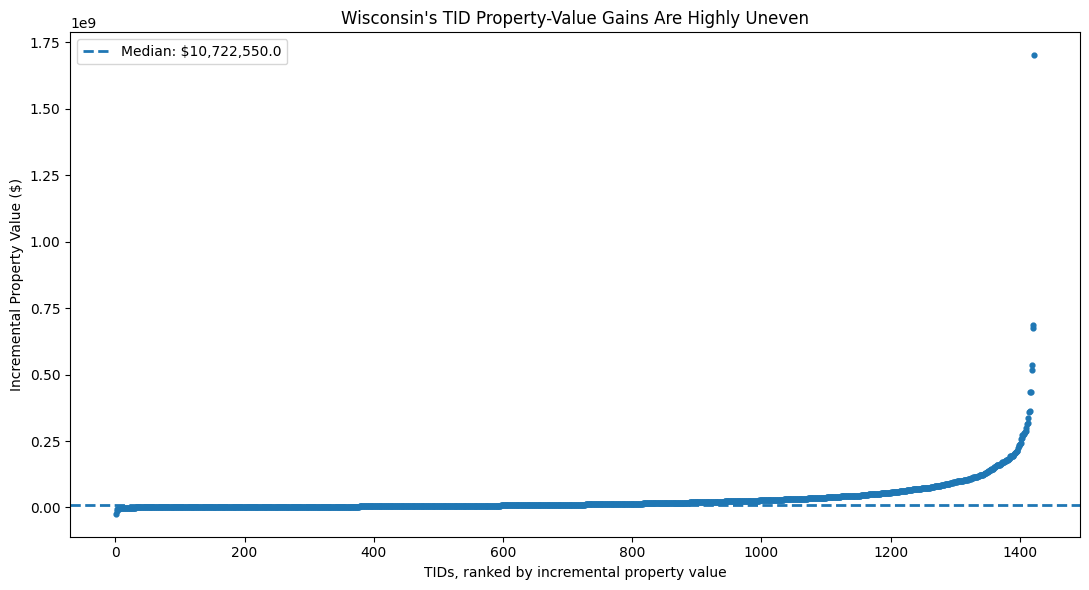

In [26]:
import matplotlib.pyplot as plt

# Sort TIDs by incremental value

ranked_tids = (
    df_2025_clean
    .sort_values("Increment")
    .reset_index(drop=True)
)

plt.figure(figsize=(11, 6))

plt.scatter(
    range(1, len(ranked_tids) + 1),
    ranked_tids["Increment"],
    s=12
)

# Median line

plt.axhline(
    median_increment_all,
    linestyle="--",
    linewidth=2,
    label=f"Median: ${median_increment_all:,.1f}"
)

plt.title(
    "Wisconsin's TID Property-Value Gains Are Highly Uneven"
)

plt.xlabel("TIDs, ranked by incremental property value")
plt.ylabel("Incremental Property Value ($)")

plt.legend()

plt.tight_layout()
plt.show()

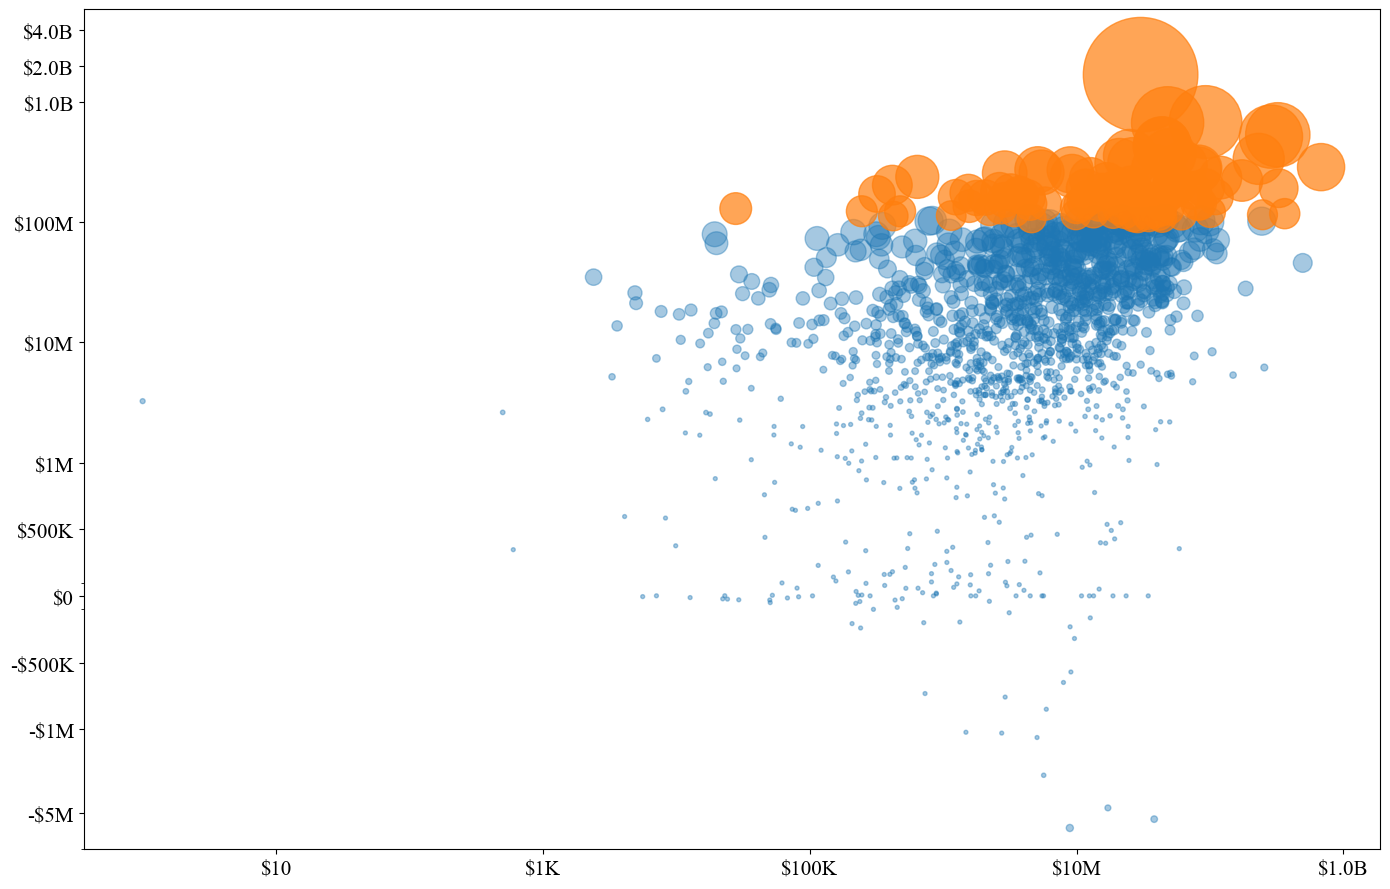

/Users/juanlasso/dataProjects/Milwaukee_Data/TID_Analysis /wisconsin_tid_bubble_chart_consistent_bubbles.png

In [94]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import FileLink, display

# --------------------------------------------------
# SET FONT
# --------------------------------------------------

plt.rcParams["font.family"] = "Times New Roman"

# --------------------------------------------------
# IDENTIFY TOP 100 TIDs BY PROPERTY-VALUE GAIN
# --------------------------------------------------

top_100_indices = (
    df_2025_clean
    .nlargest(100, "Increment")
    .index
)

# --------------------------------------------------
# USE ALL TIDs
# --------------------------------------------------

chart_tids = df_2025_clean.copy()

# --------------------------------------------------
# CALCULATE CONSISTENT BUBBLE SIZE
# --------------------------------------------------

chart_tids["Bubble Size"] = (
    abs(chart_tids["Increment"]) / 1_000_000
) * 4

# Make sure very small/zero increments remain visible
chart_tids["Bubble Size"] = chart_tids["Bubble Size"].clip(lower=8)

# Separate top 100 from the rest
top_100_chart = chart_tids[
    chart_tids.index.isin(top_100_indices)
].copy()

other_tids = chart_tids[
    ~chart_tids.index.isin(top_100_indices)
].copy()

# --------------------------------------------------
# CREATE CHART
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

# Plot all other TIDs
ax.scatter(
    other_tids["Base Value"],
    other_tids["Increment"],
    s=other_tids["Bubble Size"],
    alpha=0.4
)

# Plot top 100 TIDs
ax.scatter(
    top_100_chart["Base Value"],
    top_100_chart["Increment"],
    s=top_100_chart["Bubble Size"],
    alpha=0.7
)

# --------------------------------------------------
# X-AXIS: LOG SCALE
# --------------------------------------------------

ax.set_xscale("log")

# --------------------------------------------------
# Y-AXIS: SYMMETRIC LOG SCALE
# --------------------------------------------------

ax.set_yscale(
    "symlog",
    linthresh=1_000_000
)

# --------------------------------------------------
# FORMAT AXES AS DOLLARS
# --------------------------------------------------

def dollar_format(x, pos):
    sign = "-" if x < 0 else ""
    x = abs(x)

    if x >= 1_000_000_000:
        return f"{sign}${x / 1_000_000_000:.1f}B"
    elif x >= 1_000_000:
        return f"{sign}${x / 1_000_000:.0f}M"
    elif x >= 1_000:
        return f"{sign}${x / 1_000:.0f}K"
    else:
        return f"{sign}${x:.0f}"

formatter = FuncFormatter(dollar_format)

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

# --------------------------------------------------
# CUSTOM Y-AXIS TICKS
# Cleaner spacing around zero
# --------------------------------------------------

custom_y_ticks = [
    -5_000_000,
    -1_000_000,
    -500_000,
    0,
    500_000,
    1_000_000,
    10_000_000,
    100_000_000,
    1_000_000_000,
    2_000_000_000,
    4_000_000_000
]

ax.set_yticks(custom_y_ticks)

# --------------------------------------------------
# INCREASE TICK LABEL SIZE
# --------------------------------------------------

ax.tick_params(
    axis="both",
    which="major",
    labelsize=15
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Times New Roman")

# --------------------------------------------------
# Y-AXIS RANGE
# --------------------------------------------------

ax.set_ylim(
    -10_000_000,
    6_000_000_000
)

# --------------------------------------------------
# REMOVE ALL HEADLINES AND AXIS LABELS
# --------------------------------------------------

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")

# --------------------------------------------------
# FINALIZE AND SAVE
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "wisconsin_tid_bubble_chart_consistent_bubbles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Create clickable download link
display(
    FileLink("wisconsin_tid_bubble_chart_consistent_bubbles.png")
)